<a href="https://www.kaggle.com/code/sonawanelalitsunil/uae-used-cars-market-analysis-ml-77?scriptVersionId=230710290" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/uae-used-cars-analysis-full-project-v1-0/uae_used_cars_10k.csv
/kaggle/input/uae-used-cars-analysis-full-project-v1-0/uae_car_analysis_project_v1.0.zip/uae car analsis/layouts.py
/kaggle/input/uae-used-cars-analysis-full-project-v1-0/uae_car_analysis_project_v1.0.zip/uae car analsis/install_deps.py
/kaggle/input/uae-used-cars-analysis-full-project-v1-0/uae_car_analysis_project_v1.0.zip/uae car analsis/README.md
/kaggle/input/uae-used-cars-analysis-full-project-v1-0/uae_car_analysis_project_v1.0.zip/uae car analsis/app.py
/kaggle/input/uae-used-cars-analysis-full-project-v1-0/uae_car_analysis_project_v1.0.zip/uae car analsis/utils.py
/kaggle/input/uae-used-cars-analysis-full-project-v1-0/uae_car_analysis_project_v1.0.zip/uae car analsis/callbacks.py
/kaggle/input/uae-used-cars-analysis-full-project-v1-0/uae_car_analysis_project_v1.0.zip/uae car analsis/requirements.txt
/kaggle/input/uae-used-cars-analysis-full-project-v1-0/uae_car_analysis_project_v1.0.zip/uae car analsis/

## Title: UAE Used Cars Market Analysis

## Description: An in-depth analysis of the UAE's used car market, covering pricing trends, popular brands, and key factors influencing sales.

## Import dataset

In [2]:
try:
    df = pd.read_csv('/kaggle/input/uae-used-cars-analysis-full-project-v1-0/uae_used_cars_10k.csv', encoding='ascii')
    print(f"Dataset loaded successfully with shape: {df.shape}")
except Exception as e:
    print("An error occurred while loading the dataset:", e)

Dataset loaded successfully with shape: (10000, 12)


In [3]:
df.head()

,Make,Model,Year,Price,Mileage,Body Type,Cylinders,Transmission,Fuel Type,Color,Location,Description
0,toyota,camry,2016,47819,156500,Sedan,4,Automatic Transmission,Gasoline,Black,Dubai,"2016 toyota camry with Rear camera, Leather se..."
1,kia,sorento,2013,61250,169543,SUV,4,Automatic Transmission,Gasoline,Grey,Abu Dhabi,"2013 kia sorento with Sunroof, Adaptive cruise..."
2,mini,cooper,2023,31861,221583,Soft Top Convertible,4,Automatic Transmission,Gasoline,Grey,Dubai,"2023 mini cooper with Adaptive cruise control,..."
3,nissan,altima,2016,110322,69754,Sedan,4,Automatic Transmission,Gasoline,Red,Dubai,"2016 nissan altima with Rear camera, Adaptive ..."
4,toyota,land-cruiser-76-series,2020,139994,71399,Pick Up Truck,4,Manual Transmission,Gasoline,White,Dubai,2020 toyota land-cruiser-76-series with Adapti...


In [4]:
df.tail()

,Make,Model,Year,Price,Mileage,Body Type,Cylinders,Transmission,Fuel Type,Color,Location,Description
9995,tesla,model-3,2018,273413,76920,Sedan,NaN,Automatic Transmission,Electric,White,Dubai,"2018 tesla model-3 with Bluetooth, Sunroof, Le..."
9996,audi,a3,2022,80053,258150,Sedan,4,Automatic Transmission,Gasoline,Red,Dubai,"2022 audi a3 with Sunroof, Bluetooth, Rear cam..."
9997,toyota,prado,2014,183381,80525,SUV,6,Automatic Transmission,Gasoline,White,Dubai,"2014 toyota prado with Rear camera, Adaptive c..."
9998,peugeot,expert,2016,40876,288305,Utility Truck,4,Automatic Transmission,Diesel,White,Dubai,"2016 peugeot expert with Navigation system, Re..."
9999,mercedes-benz,c-class,2009,150261,283648,Sedan,4,Automatic Transmission,Gasoline,White,Dubai,"2009 mercedes-benz c-class with Rear camera, N..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Make          10000 non-null  object
 1   Model         10000 non-null  object
 2   Year          10000 non-null  int64 
 3   Price         10000 non-null  int64 
 4   Mileage       10000 non-null  int64 
 5   Body Type     10000 non-null  object
 6   Cylinders     9895 non-null   object
 7   Transmission  10000 non-null  object
 8   Fuel Type     10000 non-null  object
 9   Color         10000 non-null  object
 10  Location      10000 non-null  object
 11  Description   10000 non-null  object
dtypes: int64(3), object(9)
memory usage: 937.6+ KB


In [6]:
df.describe()

,Year,Price,Mileage
count,10000.000000,1.000000e+04,10000.000000
mean,2014.472800,2.452345e+05,155161.871700
std,5.790839,4.709773e+05,83681.858983
min,2005.000000,7.183000e+03,10006.000000
25%,2009.000000,5.035250e+04,82904.000000
50%,2014.000000,1.027660e+05,154370.500000
75%,2019.000000,2.312480e+05,227551.250000
max,2024.000000,1.468698e+07,299996.000000


In [7]:
df.isnull().sum()

Make              0
Model             0
Year              0
Price             0
Mileage           0
Body Type         0
Cylinders       105
Transmission      0
Fuel Type         0
Color             0
Location          0
Description       0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(10000, 12)

In [10]:
df.dtypes

Make            object
Model           object
Year             int64
Price            int64
Mileage          int64
Body Type       object
Cylinders       object
Transmission    object
Fuel Type       object
Color           object
Location        object
Description     object
dtype: object

In [11]:
df.columns

Index(['Make', 'Model', 'Year', 'Price', 'Mileage', 'Body Type', 'Cylinders',
       'Transmission', 'Fuel Type', 'Color', 'Location', 'Description'],
      dtype='object')

## Data visualizations

In [12]:
# Set style
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

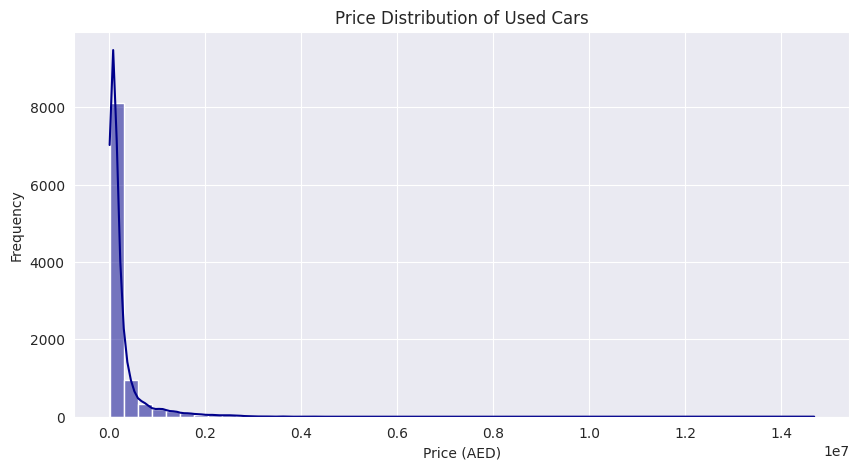

In [13]:
# 1. Price Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=50, kde=True, color='darkblue')
plt.title("Price Distribution of Used Cars")
plt.xlabel("Price (AED)")
plt.ylabel("Frequency")
plt.show()

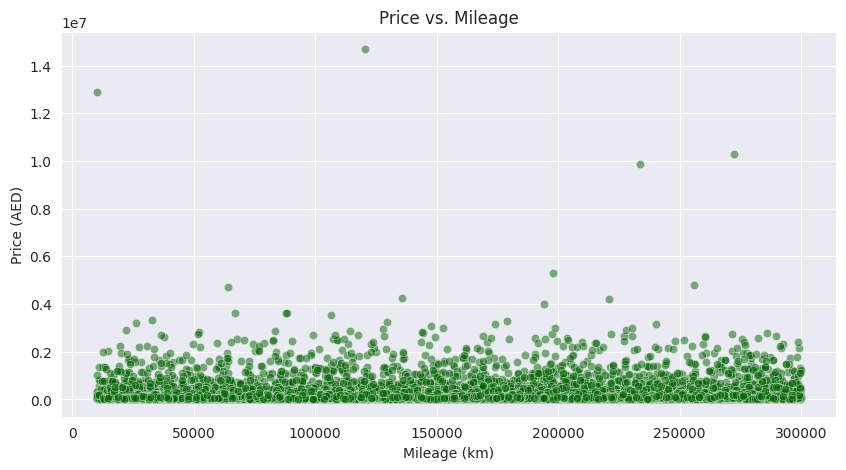

In [14]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["Mileage"], y=df["Price"], alpha=0.5, color='darkgreen')
plt.title("Price vs. Mileage")
plt.xlabel("Mileage (km)")
plt.ylabel("Price (AED)")
plt.show()

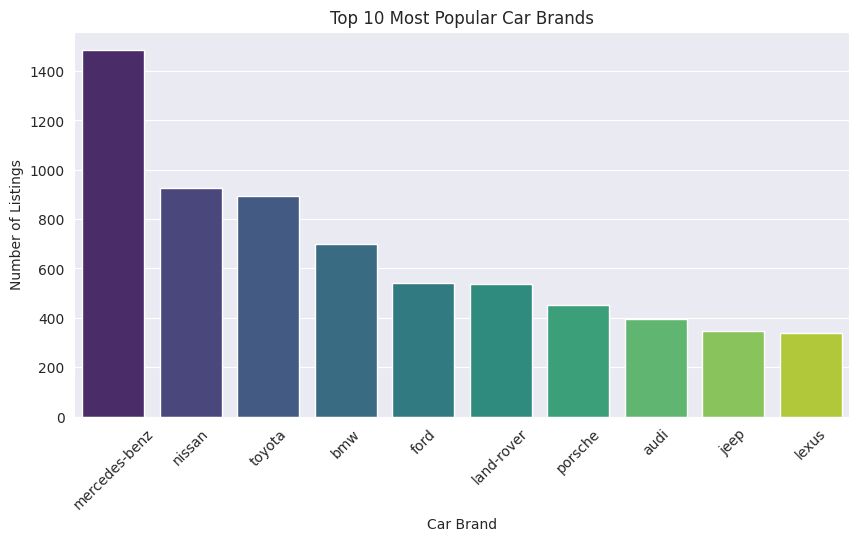

In [15]:
top_makes = df['Make'].value_counts().nlargest(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_makes.index, y=top_makes.values, palette="viridis")
plt.title("Top 10 Most Popular Car Brands")
plt.xlabel("Car Brand")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()

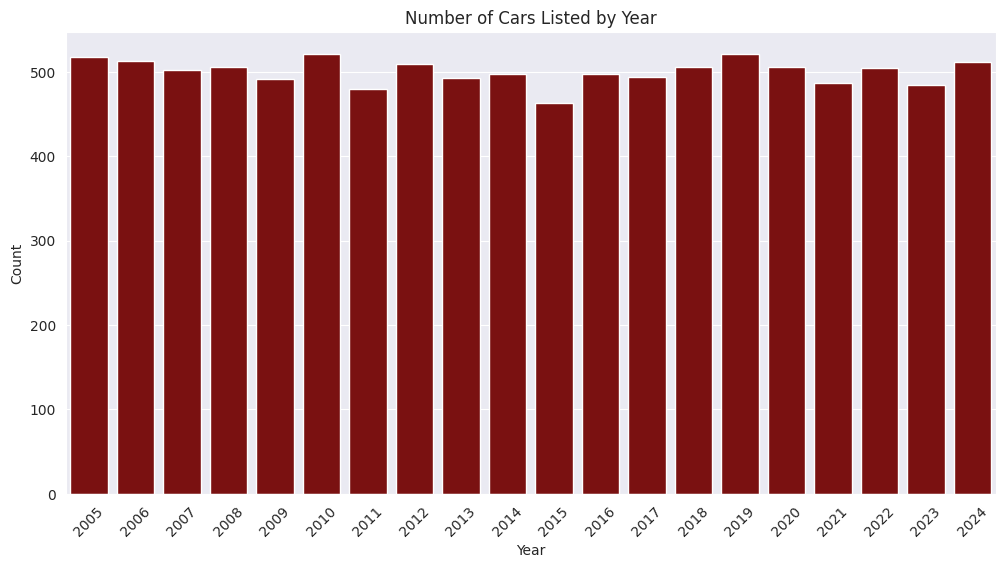

In [16]:
plt.figure(figsize=(12, 6))
sns.countplot(x=df["Year"], order=sorted(df["Year"].unique()), color='darkred')
plt.title("Number of Cars Listed by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


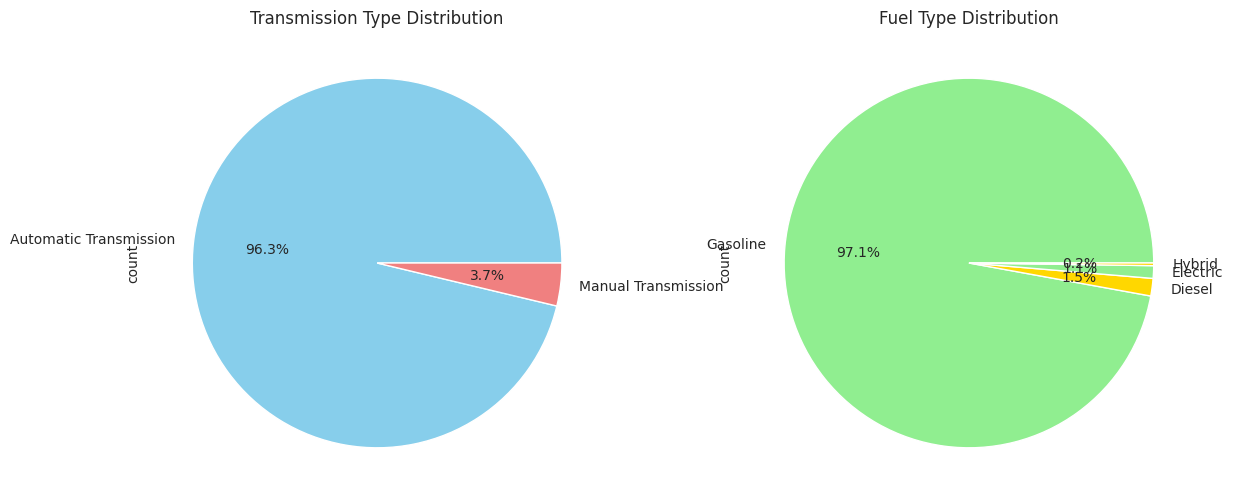

In [17]:
# 5. Transmission & Fuel Type Distribution (Pie Charts)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df['Transmission'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
axes[0].set_title("Transmission Type Distribution")

df['Fuel Type'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', colors=['lightgreen', 'gold'])
axes[1].set_title("Fuel Type Distribution")

plt.show()

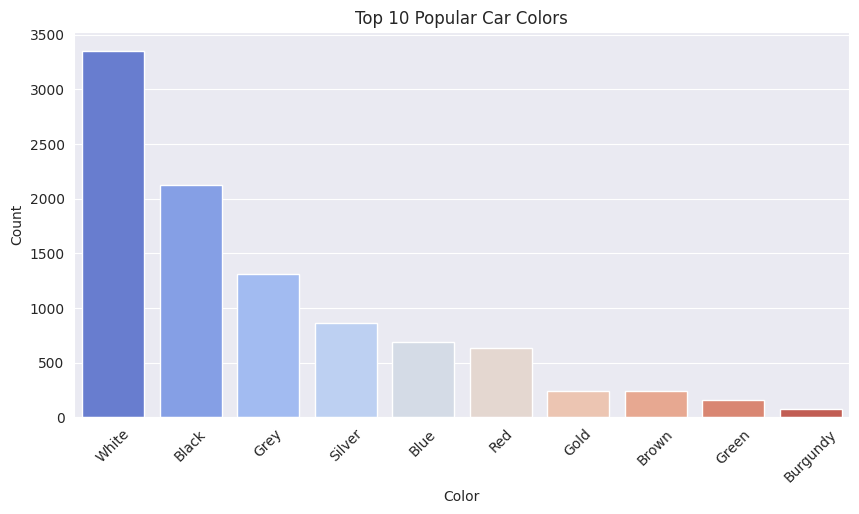

In [18]:
# 6. Color Popularity
top_colors = df['Color'].value_counts().nlargest(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_colors.index, y=top_colors.values, palette="coolwarm")
plt.title("Top 10 Popular Car Colors")
plt.xlabel("Color")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


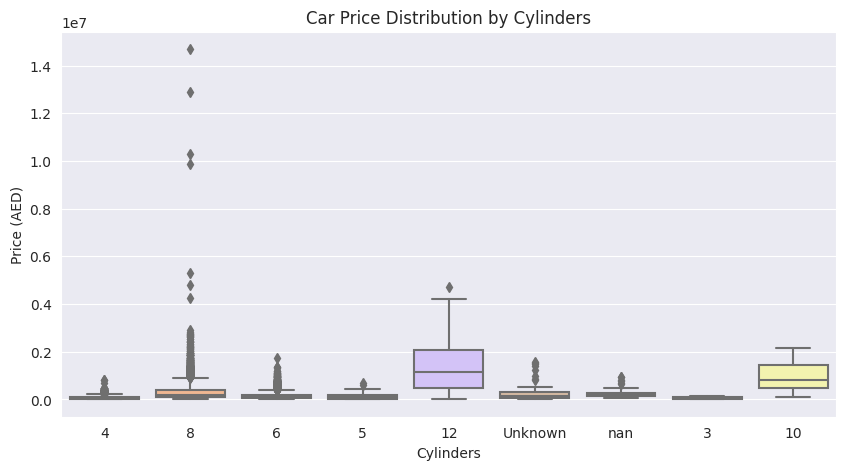

In [19]:
# 7. Cylinders vs. Price (Box Plot)
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Cylinders"].astype(str), y=df["Price"], palette="pastel")
plt.title("Car Price Distribution by Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Price (AED)")
plt.show()

## predictive modeling

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

In [22]:
df.fillna("Other", inplace=True)
df.replace("Unknown", "Other", inplace=True)

In [23]:
categorical_cols = ["Make", "Model", "Body Type", "Transmission", "Fuel Type", "Color", "Location"]

In [24]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Convert to string before encoding
    label_encoders[col] = le

In [25]:
X = df.drop(columns=["Price", "Description"])  # Drop target & text column
y = df["Price"].astype(float)  # Ensure target is numeric

In [26]:
X = X.apply(pd.to_numeric, errors='coerce')

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
results = {}

In [29]:
print("Missing values before imputation:\n", X_train.isna().sum())

Missing values before imputation:
 Make              0
Model             0
Year              0
Mileage           0
Body Type         0
Cylinders       126
Transmission      0
Fuel Type         0
Color             0
Location          0
dtype: int64


In [30]:
imputer = SimpleImputer(strategy="median")  # Use median for numerical data
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


In [31]:
# Convert back to DataFrame
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [32]:
# Confirm no NaN values
print("Missing values after imputation:\n", X_train.isna().sum())

Missing values after imputation:
 Make            0
Model           0
Year            0
Mileage         0
Body Type       0
Cylinders       0
Transmission    0
Fuel Type       0
Color           0
Location        0
dtype: int64


In [33]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42)
}

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "R² Score": r2}

In [35]:
results_df = pd.DataFrame(results).T
print(results_df)

                             MAE           MSE  R² Score
Linear Regression  220085.485883  2.140931e+11  0.183399
Decision Tree      125996.154500  1.680113e+11  0.359166
Random Forest      104216.396160  1.288908e+11  0.508380
Gradient Boosting  134120.726400  1.303805e+11  0.502698
XGBoost            111041.857303  6.002995e+10  0.771032


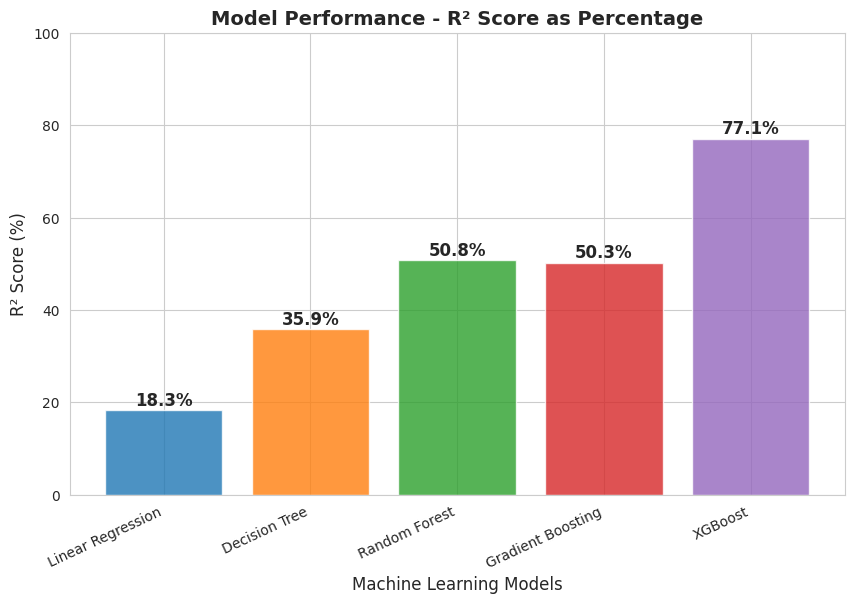

In [36]:
# Model names and R² Scores
models = ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost"]
r2_scores = [0.183399, 0.359166, 0.508380, 0.502698, 0.771032]

# Convert to percentage
r2_percentages = [score * 100 for score in r2_scores]

# Set color palette
sns.set_style("whitegrid")
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

# Plot the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(models, r2_percentages, color=colors, alpha=0.8)

# Add labels on top of bars
for bar, percent in zip(bars, r2_percentages):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{percent:.1f}%", 
             ha='center', fontsize=12, fontweight='bold')

# Labels and title
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("R² Score (%)", fontsize=12)
plt.title("Model Performance - R² Score as Percentage", fontsize=14, fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 100)

# Show the plot
plt.show()

## Thank you...pls upvote!!!!